In [53]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import os
from astropy.constants import c
from astropy import constants as const
import astropy.units as u
from scipy import special


def weight(n):
    return 2 * n**2

def boltzmann(n1, n2, eV, T):
    k = 8.6173303e-5  # Boltzmann constant in eV/K
    g_n = weight(n2) / weight(n1) * np.exp(-eV / (k * T))
    return g_n

def CIV(T):
    sigma_Lya = 5.9e-14 * (T / 1e4) ** (-1/2)
    sigma_CIV = (0.19 / 0.4164) * sigma_Lya * (12) ** (0.5)
    N_CIV_0 = 1 / sigma_CIV
    return sigma_Lya, sigma_CIV, N_CIV_0

sig_ly, sig_c, N_CIV_0 = CIV(1e5)
print("{:.5e}".format(N_CIV_0))

def tau(sig_c, x):
    return sig_c * x

rr = np.arange(12, 18, 1)
ee = [13, 20, 32, 50, 79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * ee / 10
total_N_c = total_N_c.flatten()

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm
cc = c.to(u.cm / u.s).value
v_th_1 = 11.7673179819719e5  # cm/s

K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952


NN = int(1e4)
xx = np.linspace(-3, 3, NN)
yy = np.linspace(-6,6, NN)



def Voigt(x,v_th,gamma_line, lines):
    del_lam_D = v_th / lines
    a = gamma_line / (4 * np.pi * del_lam_D)
    dy = np.abs(yy[1] - yy[0])
    
    # Broadcasting and vectorized computation
    qq_minus_yy_squared = (x[:, np.newaxis] - yy)**2
    exp_neg_yy_squared = np.exp(-yy**2)
    
    summ = np.sum(exp_neg_yy_squared * dy / (qq_minus_yy_squared + a**2), axis=1)
    
    return summ * a / np.pi

def change_x_to_lam(x,v_th ,lines):
    del_lam_D = v_th / lines
    return lines / (x * v_th / cc + 1)


def N_esc_scat(v_th):
    C_iv_N = np.linspace(1e12, 1e17, NN)
    total_tau = np.zeros((len(C_iv_N), NN))

    # 벡터화된 tau 및 Voigt 프로파일 계산
    Voigt_profile = Voigt(xx,v_th,K_gamma, C_IV_K)
    tau_profile = tau(sig_c, C_iv_N[:, None]) * Voigt_profile

    # x_0 계산
    x_0 = np.zeros(len(C_iv_N))
    for ii, jj in enumerate(C_iv_N):
        x_p = np.where(np.diff(np.sign(1 - tau_profile[ii, :])))[0]
        x_0[ii] = xx[x_p].max() if x_p.size > 0 else 0

    del_lam_D = v_th / C_IV_K
    nu_0_K= cc/C_IV_K
    nu_esc = x_0*del_lam_D + nu_0_K
    V_del_peak = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5 #km/s
    v_esc = x_0*v_th
    N_esc= 1/special.erfc(v_esc/v_th)

    return C_iv_N, N_esc , V_del_peak



3.39090e+13


In [54]:

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772
v_th_2=20e5
v_th_3=25e5
v_th_4=30e5
v_th_5 = 40e5
v_th_6=50e5
directory_1 = '~/RT/C_IV/code_tes/vv/'
# /home/jin/바탕화면/C_IV/analy , '~/바탕화면/C_IV/code_tes/data_C_IV/'
v_th = [v_th_1,v_th_2,v_th_3,v_th_4,v_th_5,v_th_6]
# v_th = [v_th_1]
v_loc = [118,200,250,300,400,500]
# v_loc = [118]

# Tem = [1e5,5e5,10e5]
Tem = [1e5]

rr = np.arange(12, 18, 1)
ee = [13, 20, 32, 50, 79]

for tt,uu in enumerate(v_loc):
    n = 0 
    globals()[f'V_K_peak_{uu}'] = np.zeros(len(rr)*len(ee))
    globals()[f'V_H_peak_{uu}'] = np.zeros(len(rr)*len(ee))
    globals()[f'scat_{uu}'] = np.zeros(len(rr)*len(ee))
    globals()[f'xx_{uu}']= np.zeros(len(rr)*len(ee))
    iou = 1e5
    sig_ly, sig_c, N_CIV_0 = CIV(iou)
    globals()[f'C_iv_{uu}'],globals()[f'N_scat_{uu}'],globals()[f'V_del_peak_{uu}'] = N_esc_scat(v_th[tt])

    
    for ii, num in enumerate(rr):
        for jj, bb in enumerate(ee):
            path_sp = f'{directory_1}N_atom{bb}0E+{num}_Vexp000E+00_Vemit100E+00_tauD000E+00_Vran{uu}E+01spec_com.dat'

            # Read data
            globals()[f'data_sp_{uu}_{bb}_{num}'] = pd.read_csv(path_sp, sep='\s+', header=None)
            globals()[f'sp_dlam_{uu}_{bb}_{num}'] = globals()[f'data_sp_{uu}_{bb}_{num}'][0]
            globals()[f'sp_{uu}_{bb}_{num}'] = globals()[f'data_sp_{uu}_{bb}_{num}'][2]

            lam_c = (C_IV_K_A+C_IV_H_A)/2
            globals()[f'lambda_K_{uu}_{bb}_{num}'] = globals()[f'sp_dlam_{uu}_{bb}_{num}'] [globals()[f'sp_dlam_{uu}_{bb}_{num}'] <= lam_c]
            globals()[f'lambda_H_{uu}_{bb}_{num}'] = globals()[f'sp_dlam_{uu}_{bb}_{num}'] [globals()[f'sp_dlam_{uu}_{bb}_{num}'] >= lam_c]

            globals()[f'flux_K_{uu}_{bb}_{num}'] = globals()[f'sp_{uu}_{bb}_{num}'] [globals()[f'sp_dlam_{uu}_{bb}_{num}'] <= lam_c]
            globals()[f'flux_H_{uu}_{bb}_{num}'] = globals()[f'sp_{uu}_{bb}_{num}'] [globals()[f'sp_dlam_{uu}_{bb}_{num}'] >= lam_c]

            X_K_P = globals()[f'lambda_K_{uu}_{bb}_{num}'][globals()[f'lambda_K_{uu}_{bb}_{num}'] >= C_IV_K_A].to_numpy()
            X_K_N = globals()[f'lambda_K_{uu}_{bb}_{num}'][globals()[f'lambda_K_{uu}_{bb}_{num}'] <= C_IV_K_A].to_numpy()
            filtered_series_K_pos_1 = globals()[f'flux_K_{uu}_{bb}_{num}'][globals()[f'lambda_K_{uu}_{bb}_{num}'] >= C_IV_K_A].to_numpy()
            filtered_series_K_neg_1 = globals()[f'flux_K_{uu}_{bb}_{num}'][globals()[f'lambda_K_{uu}_{bb}_{num}'] <= C_IV_K_A].to_numpy()

            X_H_P = globals()[f'lambda_H_{uu}_{bb}_{num}'][globals()[f'lambda_H_{uu}_{bb}_{num}'] >= C_IV_H_A].to_numpy()
            X_H_N = globals()[f'lambda_H_{uu}_{bb}_{num}'][globals()[f'lambda_H_{uu}_{bb}_{num}'] <= C_IV_H_A].to_numpy()
            filtered_series_H_pos_1 = globals()[f'flux_H_{uu}_{bb}_{num}'][globals()[f'lambda_H_{uu}_{bb}_{num}'] >= C_IV_H_A].to_numpy()
            filtered_series_H_neg_1 = globals()[f'flux_H_{uu}_{bb}_{num}'][globals()[f'lambda_H_{uu}_{bb}_{num}'] <= C_IV_H_A].to_numpy()

            # Get peak indices
            K_p_1 = np.argmax(filtered_series_K_pos_1)
            K_n_1 = np.argmax(filtered_series_K_neg_1)

            H_p_1 = np.argmax(filtered_series_H_pos_1)
            H_n_1 = np.argmax(filtered_series_H_neg_1)

            lam_K_R = X_K_P[K_p_1]
            lam_K_B = X_K_N[K_n_1]
            
            lam_H_R = X_H_P[H_p_1]
            lam_H_B = X_H_P[H_n_1]

        
            Dlam = lam_K_R - lam_K_B
            if Dlam >= 0.1 :
                del_V_peak_K =(Dlam/C_IV_K_A) * cc /1e5
            else :
                del_V_peak_K = 0        
            globals()[f'V_K_peak_{uu}'][n] = del_V_peak_K
            globals()[f'xx_{uu}'][n] = 10**num * bb / 10
            # print(globals()[f'V_K_peak_{uu}'][n])

            path_scat = f'{directory_1}N_atom{bb}0E+{num}_Vexp000E+00_Vemit100E+00_tauD000E+00_Vran{uu}E+01_f_esc.dat'

            globals()[f'data_scat_{uu}_{bb}_{num}'] = pd.read_csv(path_scat, sep='\s+', header=None)
            
            globals()[f'scat_{uu}'][n] = float(globals()[f'data_scat_{uu}_{bb}_{num}'].iloc[0,4])


            n += 1

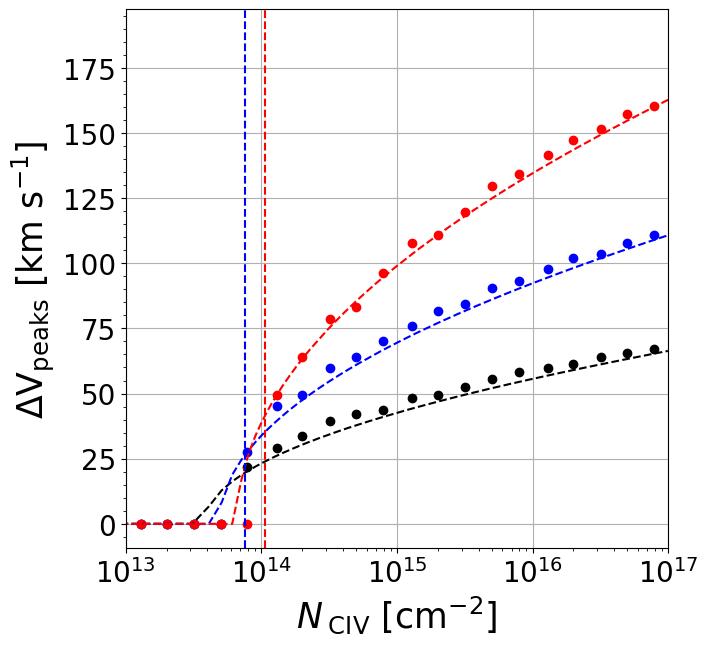

In [60]:
fig = plt.figure(1,figsize=(7,7))
plt.plot(xx_118,V_K_peak_118,'ko')
plt.plot(xx_200,V_K_peak_200,'bo')
plt.plot(xx_300,V_K_peak_300,'ro')
plt.plot(C_iv_118,V_del_peak_118,'k--')
plt.plot(C_iv_200,V_del_peak_200,'b--')
plt.plot(C_iv_300,V_del_peak_300,'r--')
# plt.axvline(x=C_iv_118,ymin=0,ymax=80,color='k',linestyle='--',label='${\mathrm{V_{th}}} = 11.8$ km s$^{-1}$')
plt.axvline(x=7.58e+13,ymin=0,ymax=80,color='b',linestyle='--',label='${\mathrm{V_{th}}} = 26.3$ km s$^{-1}$')
plt.axvline(x=1.07230e+14,ymin=0,ymax=80,color='r',linestyle='--',label='${\mathrm{V_{th}}} = 37.2$ km s$^{-1}$')

plt.xlabel(r'${N} \, _{\mathrm{C IV}}$ [cm$^{-2}$]',fontsize =25)
plt.xscale('log')
plt.xlim(10**13,10**17)
# plt.ylim(V_K_peak_1.min()-2,V_K_peak_1.max()+2)
plt.ylabel(r'$\Delta \mathrm{V}_{\mathrm{peaks}}$ [km s$^{-1}$]',fontsize =25)
plt.minorticks_on()
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid()
# plt.legend(fontsize=20,loc='upper left')


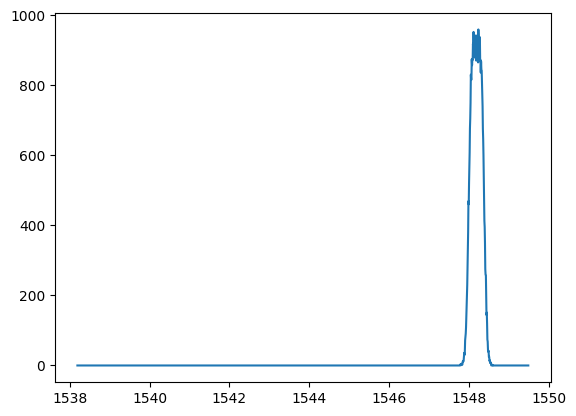

In [56]:
uu = 263
bb = 79
num = 13

plt.plot(globals()[f'lambda_K_{uu}_{bb}_{num}'],globals()[f'flux_K_{uu}_{bb}_{num}'] )

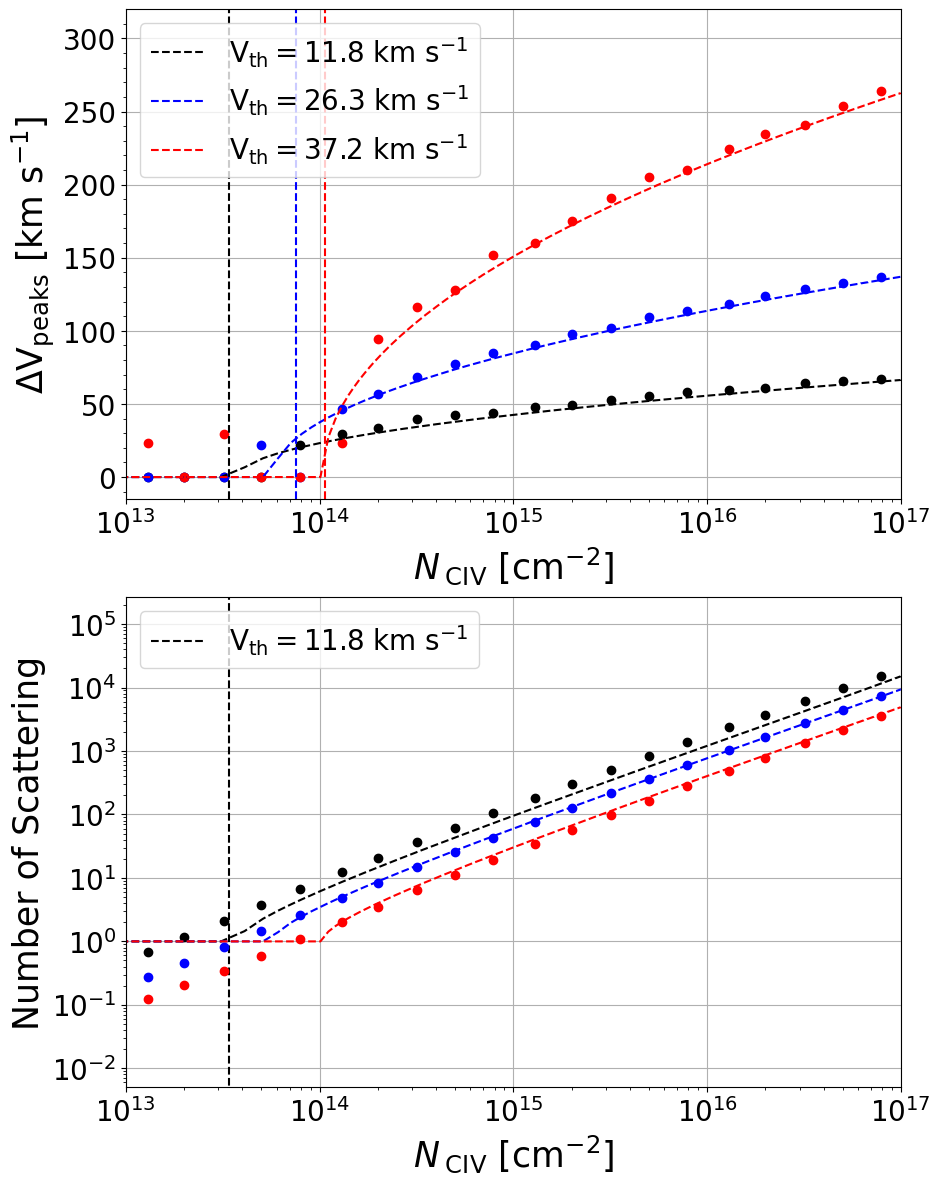

In [57]:
fig = plt.figure(1,figsize=(10,14))
# aa = np.where(x_0 > 0)
# xa= x_0[aa]

plt.subplot(211)
plt.plot(xx_118,V_K_peak_118,'ko')
plt.plot(xx_250,V_K_peak_250,'bo')
plt.plot(xx_500,V_K_peak_500,'ro')
plt.plot(C_iv_118,V_del_peak_118,'k--')
plt.plot(C_iv_250,V_del_peak_250,'b--')
plt.plot(C_iv_500,V_del_peak_500,'r--')
plt.axvline(x=3.39e13,ymin=0,ymax=80,color='k',linestyle='--',label='${\mathrm{V_{th}}} = 11.8$ km s$^{-1}$')
plt.axvline(x=7.58e+13,ymin=0,ymax=80,color='b',linestyle='--',label='${\mathrm{V_{th}}} = 26.3$ km s$^{-1}$')
plt.axvline(x=1.07230e+14,ymin=0,ymax=80,color='r',linestyle='--',label='${\mathrm{V_{th}}} = 37.2$ km s$^{-1}$')



plt.xlabel(r'${N} \, _{\mathrm{C IV}}$ [cm$^{-2}$]',fontsize =25)
plt.xscale('log')
plt.xlim(10**13,10**17)
# plt.ylim(V_K_peak_1.min()-2,V_K_peak_1.max()+2)
plt.ylabel(r'$\Delta \mathrm{V}_{\mathrm{peaks}}$ [km s$^{-1}$]',fontsize =25)
plt.minorticks_on()
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid()
plt.legend(fontsize=20,loc='upper left')

plt.subplot(212)
plt.plot(xx_118,scat_118,'ko')
plt.plot(C_iv_118,N_scat_118,'k--')
plt.axvline(x=3.39e13,ymin=N_scat_118.min()-10,ymax=2,color='k',linestyle='--',label='${\mathrm{V_{th}}} = 11.8$ km s$^{-1}$')

plt.plot(xx_250,scat_250,'bo')
plt.plot(C_iv_250,N_scat_250,'b--')
# plt.axvline(x=7.58e13,ymin=N_scat_252.min()-10,ymax=2,color='b',linestyle='--',label='${\mathrm{V_{th}}} = 26.3$ km s$^{-1}$')

plt.plot(xx_500,scat_500,'ro')
plt.plot(C_iv_500,N_scat_500,'r--')
# plt.axvline(x=1.07e14,ymin=N_scat_372.min()-10,ymax=2,color='r',linestyle='--',label='${\mathrm{V_{th}}} = 37.2$ km s$^{-1}$')


plt.xlabel(r'${N} \, _{\mathrm{C IV}}$ [cm$^{-2}$]',fontsize =25)
plt.xscale('log')
plt.yscale('log')
plt.xlim(10**13,10**17)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.ylim(scat.min(),scat.max()+2)
plt.ylabel(r'Number of Scattering',fontsize =25)
plt.minorticks_on()
plt.grid()
plt.legend(fontsize=20,loc='upper left')


# plt.savefig('/home/jin/바탕화면/simulation_vs_analyvic_jin_test.pdf',bbox_inches="tight")

